<a href="https://colab.research.google.com/github/edoardochiarotti/class_datascience/blob/main/2024/03_EDA-Visualization/03_EDA_Practice.ipynb" target="_blank" rel="noopener"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# PACKAGES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px

# EDA Practice

<img src='https://miro.medium.com/v2/resize:fit:750/format:webp/1*bNSd-pm4XjkOV7uSTNAfnA.jpeg' width="450">

Source: [EDA, Data Preprocessing, Feature Engineering: We are different!](https://medium.com/@ndleah/eda-data-preprocessing-feature-engineering-we-are-different-d2a5fa09f527), Leah Nguyen

## Content

>  More than anything, EDA is a state of mind ([Grolemund & Wickham, 2016](https://r4ds.had.co.nz/exploratory-data-analysis.html))

Exploratory Data Analysis (EDA) is the very first step before developing a statistical or ML model to answer business problems. Our goal is to get acquainted with the important traits of our data set by using descriptive statistics and visualization tools. To learn more about descriptive statistics, graphs and graph libraries in Python, you should read the notebook "03_EDA_Data-visualization". 

In this notebook, we will explore some indicators from [The Quality of Government Environmental Indicators Dataset](https://www.gu.se/en/quality-government/qog-data/data-downloads/environmental-indicators-dataset). Instead on importing the raw data, we will pick it up from where we left off in our previous practice on data cleaning, importing the dataset we created in that notebook. 

*Reference: Povitkina, Marina, Natalia Alvarado Pachon & Cem Mert Dalli. 2021. The Quality of Government Environmental Indicators Dataset, version Sep21. University of Gothenburg: The Quality of Government Institute, https://www.gu.se/en/quality-government*

We will apply the [recipe to empirically answer any question quickly](https://medium.com/towards-data-science/a-recipe-to-empirically-answer-any-question-quickly-22e48c867dd5) by Quentin Gallea, exploring how climate change and consumption patterns affect biodiversity, and more precisely, fishing biocapacity. We will follow these steps:

- [Select our ingredients](#select-ingredients)
- [Pick the right quantity of each ingredient](#pick-ingredients)
- [Tasting and preparing the ingredients (univariate analysis)](#taste-ingredients)
- [Cooking the ingredients together (bivariate analysis)](#cooking-ingredients)
- [Tasting the new recipe](#tasting-ingredients)



**We imported packages at the top of this notebook, do not forget to run the top cell to import the necessary packages!** Feel free to import other libraries if needed.


## Select our ingredients <a name="select-ingredients"></a>

<img src='https://i.imgflip.com/815iqf.jpg' width="500">


Let's import the CSV file "df_qog_polity", obtained from our last practice.

In [2]:
url = 'https://raw.githubusercontent.com/thurmboris/Data-Science_4_Sustainability/main/data/df_qog_polity.csv'
df = pd.read_csv(url)

Our first step is to select our ingredients, i.e., the variables we are interested in. 

In this notebook we will explore the following question:

*How do sea surface temperature (SST) anomalies affect fishing ground biocapacity?*

We could think that SST anomalies is reducing the biosphere's ability to produce seafood. Indeed, since most marine animals live in the upper layers of the water body, excess temperature could diminish the livability of these layers, forcing fishes to migrate, for example, to deeper zones, in turn affecting their ability to reproduce because:
- eggs may properly develop only at given temperature,
- changes in natural characteristics (e.g., terrain) may make breeding impossible, 
- changes in local food chain could make breeding more difficult.

In addition, a high fish consumption could exert additional pressure on the biosphere, while more stringent environmental regulation could lower this pressure. Hence we should also consider these factors in our analysis. 

Is our assumption correct? Let's explore! 

Here are the variables that we selected to answer our research question:
- **outcome variable**: Fishing ground biocapacity per capita (ef_fg_bc), which is the ability of a biosphere to produce seafood (the amount of fishing grounds available, weighted by the productivity of fishing grounds) per capita;
- **main explanatory variable**: SST anomalies (ohi_csst), which is the number of positive temperature deviations (anomalies) that exceed the natural range of variation for a given location, i.e., the frequency with which a location experiences unnaturally warm temperature;
- **additional explanatory variable**: Fish footprint of consumption (gha per person) (ef_fg), calculated based on estimates of the maximum sustainable catch for a variety of fish species.
- **additional explanatory variable**:  Number of climate change laws and policies (ccl_nlp), which is the cumulative sum of laws (legislative acts) and policies (executive provisions) related to climate change

You can learn more about these variables in the [QoG codebook](https://www.qogdata.pol.gu.se/data/codebook_ei_sept21_august2023.pdf). 

Ok, let's extract these variables:

- Extract in a new dataframe the columns 'iso3', 'year', 'cname_qog', 'ef_fg_bc', 'ohi_csst', 'ef_fg', and 'ccl_nlp'.
- Rename the column 'cname_qog' as 'country'
- Display your dataframe

In [3]:
# Select our variables and rename the country column
cols = ['iso3', 'year', 'cname_qog', 'ef_fg_bc', 'ohi_csst', 'ef_fg', 'ccl_nlp']
df_fish = df[cols].rename(columns={'cname_qog': 'country'})
df_fish

,iso3,year,country,ef_fg_bc,ohi_csst,ef_fg,ccl_nlp
0,AFG,1946,Afghanistan,NaN,NaN,NaN,NaN
1,AFG,1947,Afghanistan,NaN,NaN,NaN,NaN
2,AFG,1948,Afghanistan,NaN,NaN,NaN,NaN
3,AFG,1949,Afghanistan,NaN,NaN,NaN,NaN
4,AFG,1950,Afghanistan,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
11717,VDR,1972,"Vietnam, South",NaN,NaN,NaN,NaN
11718,VDR,1973,"Vietnam, South",NaN,NaN,NaN,NaN
11719,VDR,1974,"Vietnam, South",NaN,NaN,NaN,NaN
11720,VDR,1975,"Vietnam, South",NaN,NaN,NaN,NaN


## Pick the right quantity of each ingredient <a name="pick-ingredients"></a>

<img src='https://i.imgflip.com/81615v.jpg' width="400">

Our objective is to explore the data availability of our variables and select a clean sample for the analysis.

- First, use the `.describe()` method ([Documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html)) to generate descriptive statistics of our variables
- What do you notice regarding the number of observations?

In [4]:
df_fish.describe()

# The 'count' row shows many missing values: 11'722 rows overall, but only 148 SST anomalies
# 6'201 ecological footprint values and 4'044 climate change law counts.

,year,ef_fg_bc,ohi_csst,ef_fg,ccl_nlp
count,11722.000000,6201.000000,148.000000,6201.000000,4044.000000
mean,1988.188193,0.626597,0.301236,0.140960,5.394906
std,20.252364,1.487357,0.163395,0.373979,5.462809
min,1946.000000,0.000000,0.000000,0.000000,1.000000
25%,1972.000000,0.042377,0.193787,0.016394,2.000000
50%,1990.000000,0.124728,0.266124,0.049547,3.000000
75%,2005.000000,0.425291,0.348327,0.135210,7.000000
max,2020.000000,17.227063,0.757147,5.596642,48.000000


Although we have 11'722 observations overall, we only have 148 non missing SST anomalies values, and 6'201 non missing ecological footprint values. Let's try to better understand where those missing values are coming from.

- Create a new dataframe grouping the observations by year and counting the number of non missing values for the variables 'ef_fg_bc', 'ohi_csst', and 'ef_fg'. You can use the methods `.groupby()` ([Documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.groupby.html)) and `.count()` ([Documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.count.html))
- In this new dataframe, remove the rows that have zero non missing observations for our 3 variables
- Display your new dataframe, what do you observe?

In [5]:
# Number of non missing values per year
df_count_year = df_fish.groupby('year')[['ef_fg_bc', 'ohi_csst', 'ef_fg']].count()

# Remove years with zero non missing observations for all 3 variables
df_count_year = df_count_year[(df_count_year != 0).any(axis=1)]
df_count_year

# SST anomalies are only available in 2015. The footprint variables start in 1961
# and the number of countries covered increases over time.

,ef_fg_bc,ohi_csst,ef_fg
year,,,
1961,76,0,76
1962,76,0,77
1963,80,0,80
1964,82,0,82
1965,85,0,85
1966,87,0,87
1967,90,0,90
1968,90,0,90
1969,90,0,90


Unfortunately, we only have SST anomalies for the year 2015... It will significantly limit our analysis as it prevents to exploit the time dimension. For the ecological footprint variables, our number of observations is increasing through time. To have a relatively constant sample size, we will restrict to years from 1993 to 2015. We will also only keep countries for which we have observations for our outcome variable, namely fishing ground biocapacity per capita:

- Create a new dataframe keeping only the observations between 1993 to 2015 and for which the variable 'ef_fg_bc' is not missing

In [6]:
df_sample = df_fish[(df_fish['year'] >= 1993) & (df_fish['year'] <= 2015) & (df_fish['ef_fg_bc'].notna())]
df_sample

,iso3,year,country,ef_fg_bc,ohi_csst,ef_fg,ccl_nlp
47,AFG,1993,Afghanistan,0.000000,NaN,0.000124,NaN
48,AFG,1994,Afghanistan,0.000000,NaN,0.000126,NaN
49,AFG,1995,Afghanistan,0.000000,NaN,0.000120,NaN
50,AFG,1996,Afghanistan,0.000000,NaN,0.000114,NaN
51,AFG,1997,Afghanistan,0.000000,NaN,0.000107,NaN
...,...,...,...,...,...,...,...
11526,ZMB,2011,Zambia,0.023636,NaN,0.013431,8.0
11527,ZMB,2012,Zambia,0.022913,NaN,0.017987,8.0
11528,ZMB,2013,Zambia,0.022314,NaN,0.024079,8.0
11529,ZMB,2014,Zambia,0.021707,NaN,0.035119,9.0


Let's visualize our geographical coverage!

- Create a new dataframe counting the number of observations for each iso 3 code
- Create an interactive map displaying the number of observations for each country. Do not forget to add a title to your graph. You can also use different [color theme](https://plotly.com/python/builtin-colorscales/). What do you think?

In [7]:
# Number of observations per country
df_count_country = df_sample.groupby(['iso3', 'country']).size().reset_index(name='n_obs')

fig = px.choropleth(df_count_country,
                    locations='iso3',
                    color='n_obs',
                    hover_name='country',
                    color_continuous_scale='Viridis',
                    title='Number of observations per country (1993-2015)')
fig.show()

We have a nice geographical coverage, covering all continents, and most countries have +20 observations. Cool!

## Tasting and preparing the ingredients (univariate analysis) <a name="taste-ingredients"></a>

<img src='https://i.imgflip.com/81630v.jpg' width="500">

Our objectives are threefold:
- Prepare the data: by studying the distribution of the variables, we will decide if we should transform the data (e.g., log-transform, define a categorical variable, deal with outliers, etc.)
- Choose the right statistical tools: knowing the nature of each variable (continuous, categorical, binary, etc.) will allows us to choose the right statistical tools (correlation, bar/line graphs, scatter plot, etc).
- Get an idea of the underlying variation: looking at how the variable varies over time (line graph) and space (map), will help us better understand the data and potentially spot some anomalies or interesting shocks to exploit for a natural experiment.

Ok, before digging more carefully into each variable, let's have an overview of how our variables are distributed:

- Display descriptive statistics for our selected sample

In [8]:
df_sample.describe()

,year,ef_fg_bc,ohi_csst,ef_fg,ccl_nlp
count,2940.000000,2940.000000,94.000000,2939.000000,1941.000000
mean,2004.075510,0.564536,0.290337,0.121932,4.470376
std,6.624915,1.350069,0.151420,0.246350,4.164377
min,1993.000000,0.000000,0.000000,0.000037,1.000000
25%,1998.000000,0.026004,0.201663,0.018318,2.000000
50%,2004.000000,0.089586,0.262497,0.052246,3.000000
75%,2010.000000,0.338614,0.334437,0.135160,6.000000
max,2015.000000,11.602198,0.732453,3.614244,29.000000


- Create box plots of the variables 'ef_fg_bc', 'ohi_csst', and 'ef_fg'. What do you observe?

*Note: you can create several plots next to each other by using `fig, ax = plt.subplots(1, 3, figsize=(10, 5))`. In `plt.subplots(1,3,figsize=(10,5))`, 1 refers to the number of rows, and 3 to the number of columns: here we would have 3 plots next to each other. You specify the location of each plot thanks to `ax`: here `ax[0]` would be the left plot, `ax[1]` the middle one, and `ax[2]` the right one.*

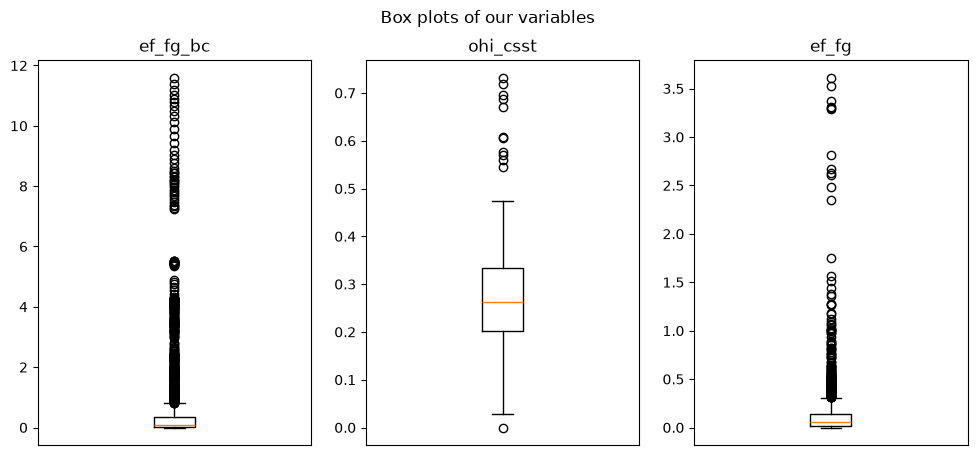

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5))

for i, var in enumerate(['ef_fg_bc', 'ohi_csst', 'ef_fg']):
    ax[i].boxplot(df_sample[var].dropna())
    ax[i].set_title(var)
    ax[i].set_xticks([])

plt.suptitle('Box plots of our variables')
plt.show()

# 'ef_fg_bc' and 'ef_fg' have many outliers far above the box (right-skewed),
# while 'ohi_csst' looks more symmetric.

It seems that our ecological footprint variables have a lot of outliers. In other words, they are highly-skewed. Let's continue the exploration.

### Fishing ground biocapacity per capita

Let's explore our first variable, namely the fishing ground biocapacity per capita

- Plot a histogram of the column 'ef_fg_bc'

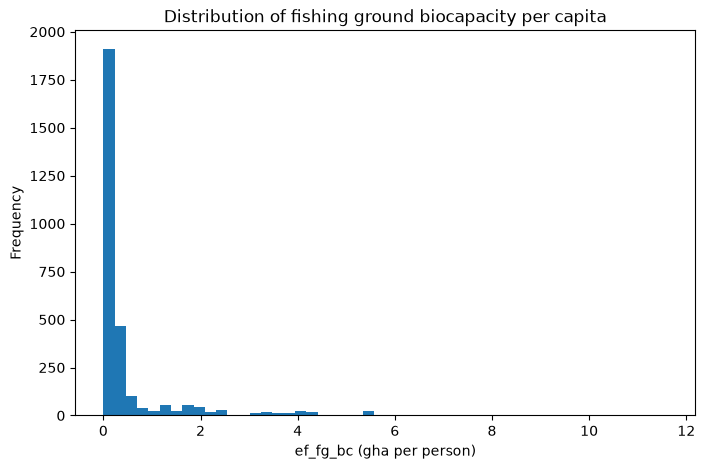

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df_sample['ef_fg_bc'], bins=50)
plt.title('Distribution of fishing ground biocapacity per capita')
plt.xlabel('ef_fg_bc (gha per person)')
plt.ylabel('Frequency')
plt.show()

The histogram confirms that our variable is highly skewed.

- Print the skewness of the variable 'ef_fg_bc'

In [11]:
print('Skewness of ef_fg_bc:', df_sample['ef_fg_bc'].skew())

Skewness of ef_fg_bc: 4.315013556458132


The skewness is very high. As a rule of thumb, when the skewness is larger than 3, it is a good idea to do a log transformation. However, we have another issue here: it seems that many observations may be equal to zero. To better understand what is happening, let's check for which countries we have values equal to 0.

- Print the countries that have at least one observation equal to zero for the column 'ef_fg_bc'

In [12]:
zero_countries = df_sample.loc[df_sample['ef_fg_bc'] == 0, 'country'].unique()
print(len(zero_countries), 'countries have at least one zero value:')
print(zero_countries)

4 countries have at least one zero value:
<ArrowStringArray>
['Afghanistan', 'Central African Republic', 'Lesotho', 'South Sudan']
Length: 4, dtype: str


We could have assumed that the fishing group biocapacity was zero for countries without access to the sea. However, this is not the case (probably because our variable also includes freshwater fishing ground). Hence, the observations equal to zero may simply be missing values. We will remove them, which will simplify our analysis.

- For our "selected sample" dataframe, remove the observations for which 'ef_fg_bc' is equal to zero.
- Display the new descriptive statistics

In [13]:
df_sample = df_sample[df_sample['ef_fg_bc'] != 0].copy()
df_sample.describe()

,year,ef_fg_bc,ohi_csst,ef_fg,ccl_nlp
count,2867.000000,2867.000000,94.000000,2866.000000,1912.000000
mean,2004.064179,0.578910,0.290337,0.124862,4.481695
std,6.619828,1.364107,0.151420,0.248773,4.184354
min,1993.000000,0.000556,0.000000,0.000037,1.000000
25%,1998.000000,0.030388,0.201663,0.021395,2.000000
50%,2004.000000,0.098446,0.262497,0.054359,3.000000
75%,2010.000000,0.346428,0.334437,0.137085,6.000000
max,2015.000000,11.602198,0.732453,3.614244,29.000000


Alright, now we can transform our data.

- Log transform the column 'ef_fg_bc'. You can for instance use the `log` function of the `numpy` library ([Documentation](https://numpy.org/doc/stable/reference/generated/numpy.log.html)), and create a new column 'ef_fg_bc_log' in our dataframe.
- Plot a histogram of your log transformed data
- Check the skewness of your log transformed data

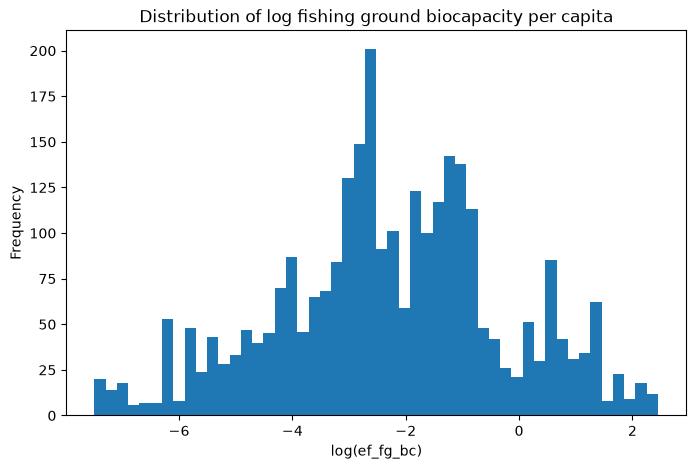

Skewness of ef_fg_bc_log: -0.13634570330034376


In [14]:
df_sample['ef_fg_bc_log'] = np.log(df_sample['ef_fg_bc'])

plt.figure(figsize=(8, 5))
plt.hist(df_sample['ef_fg_bc_log'], bins=50)
plt.title('Distribution of log fishing ground biocapacity per capita')
plt.xlabel('log(ef_fg_bc)')
plt.ylabel('Frequency')
plt.show()

print('Skewness of ef_fg_bc_log:', df_sample['ef_fg_bc_log'].skew())

Alright, much better! Let's finalize our exploration of the fishing ground biocapacity per capita by checking the geographical patterns and the evolution through time of the variable

- Plot a map of the average 'ef_fg_bc_log' for each country (average of all years). *Note: you can group rows by iso 3 codes, and then use the `.mean()` method*.
- Do you observe any geographical patterns?

In [15]:
df_bc_country = df_sample.groupby(['iso3', 'country'])['ef_fg_bc_log'].mean().reset_index()

fig = px.choropleth(df_bc_country,
                    locations='iso3',
                    color='ef_fg_bc_log',
                    hover_name='country',
                    color_continuous_scale='Blues',
                    title='Average log fishing ground biocapacity per capita (1993-2015)')
fig.show()

# Countries with large fishing grounds and small populations (e.g., Bahamas, Suriname, Guyana,
# Canada, Australia, Norway) have the highest biocapacity per capita. Landlocked countries
# (e.g., Niger, Burkina Faso, Luxembourg, Czech Republic, Slovakia) have the lowest.

- Plot the evolution of the average 'ef_fg_bc_log' (average of all countries). Do not forget labels and title! What do you observe?

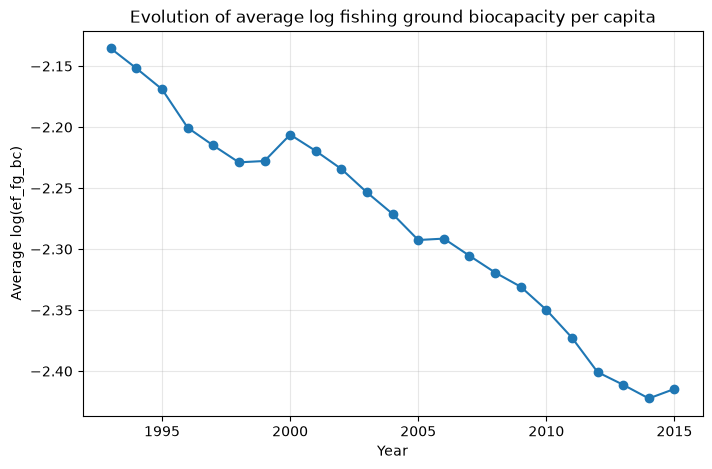

In [16]:
df_bc_year = df_sample.groupby('year')['ef_fg_bc_log'].mean()

plt.figure(figsize=(8, 5))
plt.plot(df_bc_year.index, df_bc_year.values, marker='o')
plt.title('Evolution of average log fishing ground biocapacity per capita')
plt.xlabel('Year')
plt.ylabel('Average log(ef_fg_bc)')
plt.grid(alpha=0.3)
plt.show()

# The average biocapacity per capita is decreasing over time (partly because
# population grows while fishing grounds do not).

### Sea surface temperature (SST) anomalies

Let's now explore our second variable 'ohi_csst'

- Plot a histogram of 'ohi_csst' and check the skewness. Do we need to transform our variable? If yes, transform accordingly, else, continue.
- Plot a map of the SST anomalies in 2015. What do you think? 

*Note: to avoid repeating the same lines of code, it is always a good idea to define functions! We could have done so already in the previous section, but feel free to train how to define functions here, for instance defining a function to create histograms and another one to create a map.*


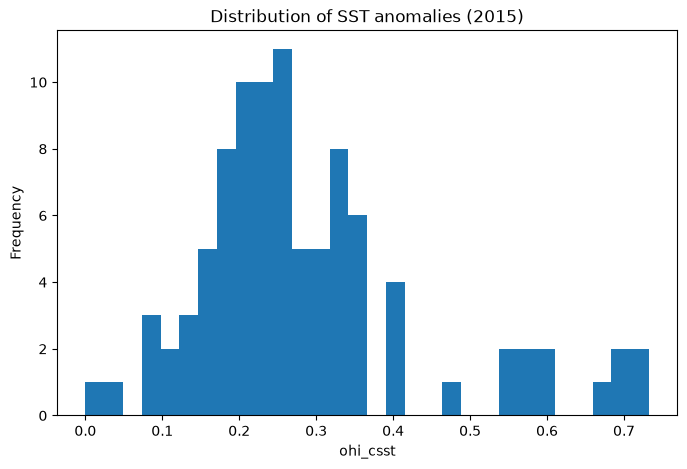

Skewness of ohi_csst: 1.2480584066030511


In [17]:
# Helper functions to avoid repeating code
def plot_hist(data, var, title, bins=30):
    plt.figure(figsize=(8, 5))
    plt.hist(data[var].dropna(), bins=bins)
    plt.title(title)
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.show()
    print(f'Skewness of {var}:', data[var].skew())

def plot_map(data, var, title, scale='Viridis'):
    fig = px.choropleth(data,
                        locations='iso3',
                        color=var,
                        hover_name='country',
                        color_continuous_scale=scale,
                        title=title)
    fig.show()

plot_hist(df_sample, 'ohi_csst', 'Distribution of SST anomalies (2015)')
# The skewness (~1.2) is moderate and well below 3, so no log transformation is needed.

plot_map(df_sample[df_sample['year'] == 2015], 'ohi_csst', 'Sea surface temperature anomalies in 2015', 'Reds')
# We only have one year and fewer than 100 countries in our sample. SST anomalies are highest
# in the Eastern Mediterranean (Israel, Lebanon, Turkey, Syria, Greece) and lowest e.g. in
# Peru and Chile. Without a time dimension, it is hard to link them to changes in biocapacity.

### Fish footprint of consumption

Let's now dive into the fish footprint of consumption.

- Plot a histogram of 'ef_fg' and check the skewness. Do we need to transform our variable? If yes, transform accordingly, else, continue.
- Plot a map of the average fish footprint of consumption per country. What do you observe? 
- Plot the evolution of the average fish footprint of consumption in the world. What do you observe?

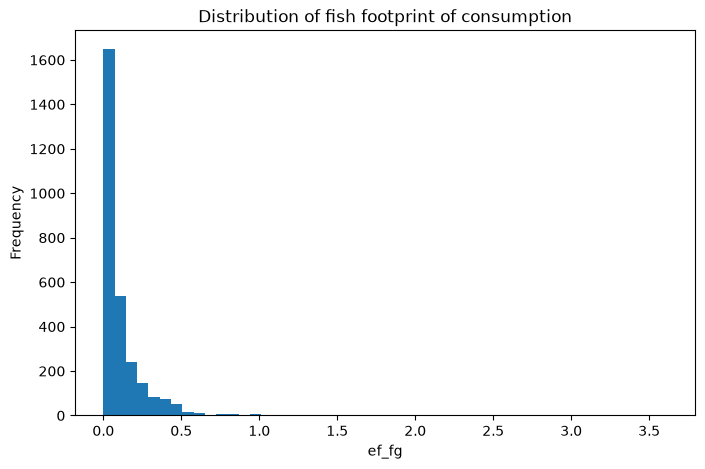

Skewness of ef_fg: 7.865653228622685
Number of zero values: 0


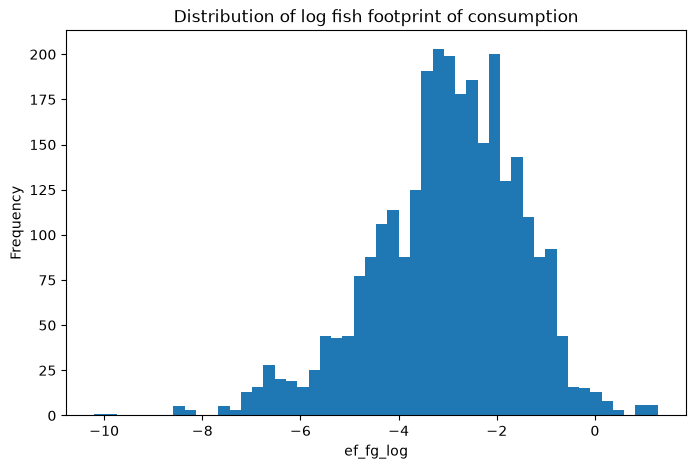

Skewness of ef_fg_log: -0.5573794529889838


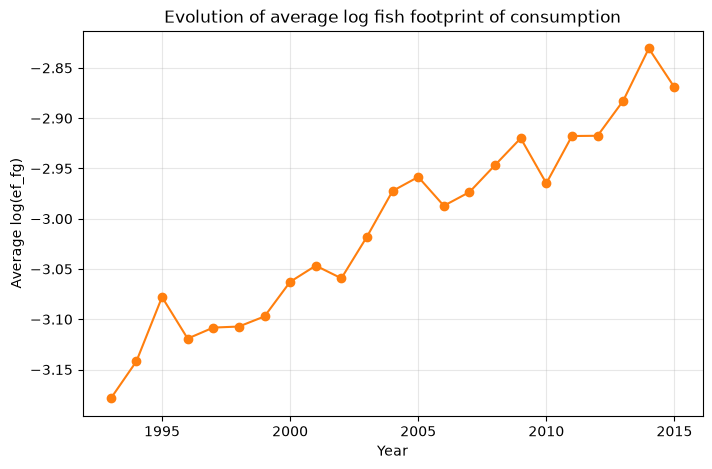

In [18]:
plot_hist(df_sample, 'ef_fg', 'Distribution of fish footprint of consumption', bins=50)
# Highly skewed -> log transform (only strictly positive values can be logged)
print('Number of zero values:', (df_sample['ef_fg'] == 0).sum())
df_sample['ef_fg_log'] = np.log(df_sample['ef_fg'].where(df_sample['ef_fg'] > 0))
plot_hist(df_sample, 'ef_fg_log', 'Distribution of log fish footprint of consumption', bins=50)

# Map of the average per country
df_fg_country = df_sample.groupby(['iso3', 'country'])['ef_fg_log'].mean().reset_index()
plot_map(df_fg_country, 'ef_fg_log', 'Average log fish footprint of consumption (1993-2015)', 'Oranges')
# Coastal, fishing-oriented countries (e.g., Norway, Denmark, Fiji, Chile, South Korea,
# Japan, Spain) have the largest fish footprint per person; landlocked countries
# (e.g., Ethiopia, Sudan, Uzbekistan, Nepal, Rwanda) have the smallest.

# Evolution through time
df_fg_year = df_sample.groupby('year')['ef_fg_log'].mean()
plt.figure(figsize=(8, 5))
plt.plot(df_fg_year.index, df_fg_year.values, marker='o', color='tab:orange')
plt.title('Evolution of average log fish footprint of consumption')
plt.xlabel('Year')
plt.ylabel('Average log(ef_fg)')
plt.grid(alpha=0.3)
plt.show()
# The fish footprint of consumption tends to increase over time,
# while biocapacity per capita decreases.

### Number of climate change laws and policies

You may have noticed, we did not discuss much the number of climate change regulations until now. Indeed, we should save it in the fridge to keep it fresh and use at the right moment! Joke aside, it is true that we will manipulate and transform this variable later - data science is not a linear process after all. For now, it is important to note that this variable is discrete, not continuous like the other variables. 

- Plot a histogram of 'ccl_nlp'.
- Plot a map of the number of climate change regulations in 2015

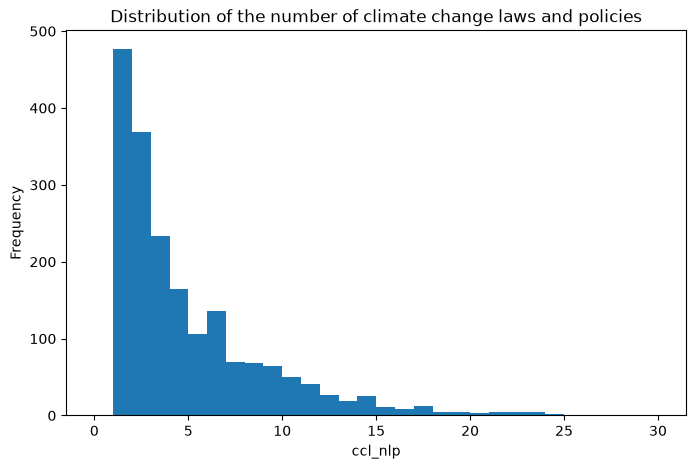

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(df_sample['ccl_nlp'].dropna(), bins=range(0, int(df_sample['ccl_nlp'].max()) + 2))
plt.title('Distribution of the number of climate change laws and policies')
plt.xlabel('ccl_nlp')
plt.ylabel('Frequency')
plt.show()

plot_map(df_sample[df_sample['year'] == 2015], 'ccl_nlp', 'Number of climate change laws and policies in 2015', 'Greens')

## Cooking the ingredients together (bivariate analysis) <a name="cooking-ingredients"></a>

<img src='https://i.imgflip.com/1e0h17.jpg' width="400">

Let's now put our ingredients together! Our goal is to detect potential associations between our variables, which will later guide our statistical analysis.

First, remember that for SST anomalies, we only had values for 2015. It is not ideal, and if we were to actually perform a statistical analysis, it would be wise to look for more data (maybe from another database?) or to use another variable (maybe temperature anomalies instead of SST anomalies?). But for now, let's proceed with the data at hand.

- Extract observations for which the variables 'ohi_csst' and 'ccl_nlp' are not missing

In [20]:
df_biv = df_sample[df_sample['ohi_csst'].notna() & df_sample['ccl_nlp'].notna()].copy()
print(df_biv.shape)
df_biv.head()

(90, 9)


,iso3,year,country,ef_fg_bc,ohi_csst,ef_fg,ccl_nlp,ef_fg_bc_log,ef_fg_log
144,ALB,2015,Albania,0.081207,0.358253,0.037020,2.0,-2.510751,-3.296308
322,AGO,2015,Angola,0.196056,0.231307,0.110688,15.0,-1.629353,-2.201041
501,ARG,2015,Argentina,1.600981,0.192856,0.092827,12.0,0.470616,-2.377020
576,AUS,2015,Australia,3.124566,0.272634,0.110520,17.0,1.139295,-2.202561
689,BHS,2015,Bahamas,8.053516,0.119851,0.114479,4.0,2.086109,-2.167364


We'll first check the correlations between our variables. Even though correlation does not imply causation, it's never a bad idea to check how our variables correlate.

- Display the correlation between the variables 'ef_fg_bc_log' (log transformed), 'ohi_csst', and 'ef_fg_log' (log transformed). *Note: you can use the `pandas` method `.corr()` ([Documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html))*
- For a more visual representation, plot a heat map of your correlation matrix. *Note: you can for instance use the `seaborn` function `heatmap()` ([Documentation](https://seaborn.pydata.org/generated/seaborn.heatmap.html))*

,ef_fg_bc_log,ohi_csst,ef_fg_log
ef_fg_bc_log,1.000000,-0.148633,0.397018
ohi_csst,-0.148633,1.000000,-0.194338
ef_fg_log,0.397018,-0.194338,1.000000


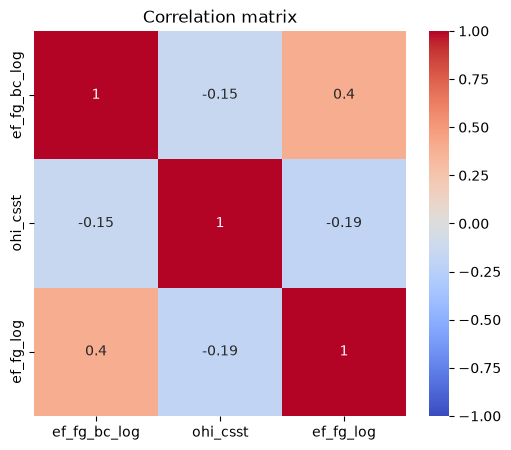

In [21]:
corr = df_biv[['ef_fg_bc_log', 'ohi_csst', 'ef_fg_log']].corr()
display(corr)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation matrix')
plt.show()

Note that the absence of (Pearson)-correlation does not indicate an absence of causation. Indeed, there could be a non-linear association between our variables! A scatter plot provides a visual tool to check the relation between our variables.

- Plot two scatter plots:
    - 'ef_fg_bc' (log transformed) vs 'ohi_csst'
    - 'ef_fg_bc' vs 'ef_fg' (both log transformed)
- What do you observe?    

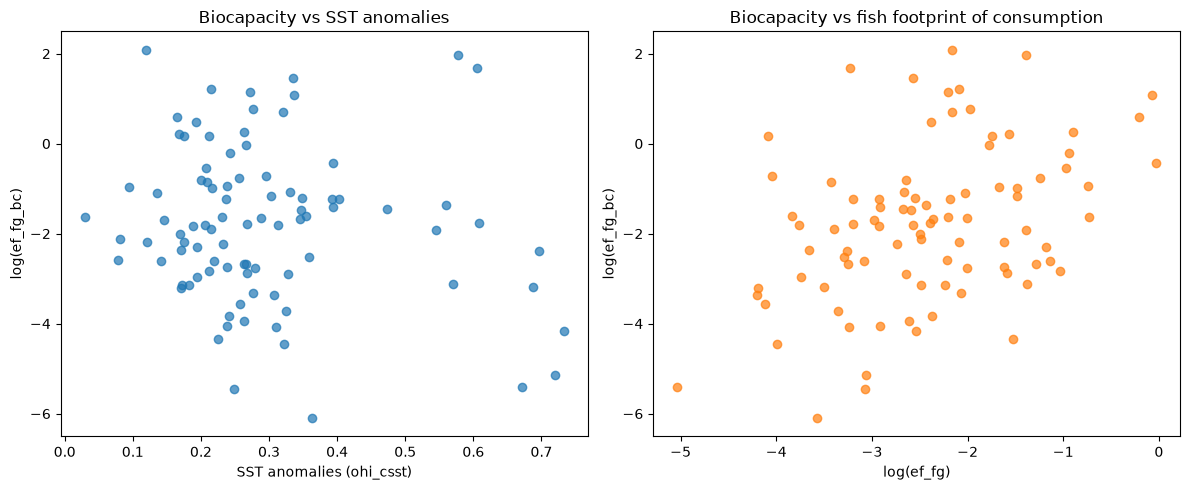

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(df_biv['ohi_csst'], df_biv['ef_fg_bc_log'], alpha=0.7)
ax[0].set_title('Biocapacity vs SST anomalies')
ax[0].set_xlabel('SST anomalies (ohi_csst)')
ax[0].set_ylabel('log(ef_fg_bc)')

ax[1].scatter(df_biv['ef_fg_log'], df_biv['ef_fg_bc_log'], alpha=0.7, color='tab:orange')
ax[1].set_title('Biocapacity vs fish footprint of consumption')
ax[1].set_xlabel('log(ef_fg)')
ax[1].set_ylabel('log(ef_fg_bc)')

plt.tight_layout()
plt.show()

# No clear relation with SST anomalies; a positive relation between biocapacity
# and fish footprint of consumption.

The relation between the fishing ground biocapacity and SST anomalies is not obvious... As for fishing ground biocapacity and fish footprint of consumption, we do have a trend! But wait, it seems that the biocapacity is increasing with the consumption?! When we checked the evolution through time of our variables, they were evolving in the opposite direction, which seemed more in line with our intuition, but here we observe a positive correlation. How is that possible? 

Well it may be an instance of [Simpson's paradox](https://en.wikipedia.org/wiki/Simpson%27s_paradox). This paradox describes phenomena in which a trend appears in several groups of data but disappears or reverses when the groups are combined. Here, it may be a good idea to group our countries by their GDP level and see if there is a relation between our variables within groups of countries. Indeed, richer countries may have both a greater fish consumption and stricter environmental norms protecting fishing biocapacity (what we observe in our scatter plot). However, for the same level of development, a higher fish footprint of consumption could lead to a lower fishing ground biocapacity (what we observe in our previous line plot). 

We did not select GDP as a variable - what a shame, however, we could still do a heterogeneity analysis using... the number of climate change regulations! Yes, it is time to take it out of the fridge! Remember that the number of climate change regulation is a discrete variable. In such case, instead of directly using the variable, it may be interesting to create clusters, e.g., countries with value above the median vs countries with value below the mean.

- Create a new column 'cluster' with values 0 for countries with 'ccl_nlp' below the median, and 1 for countries with 'ccl_nlp' above the median

In [23]:
median_ccl = df_biv['ccl_nlp'].median()
print('Median number of climate change laws and policies:', median_ccl)

df_biv['cluster'] = (df_biv['ccl_nlp'] > median_ccl).astype(int)
df_biv['cluster'].value_counts()

Median number of climate change laws and policies: 9.0


cluster
0    49
1    41
Name: count, dtype: int64

Ok, let's see how grouping our countries by clusters depending on their number of policies affect the relationship between our variables:

- Create a scatter plot of 'ef_fg_bc_log' vs 'ef_fg_log', colored by the country 'cluster'. What do you observe?

In [24]:
fig = px.scatter(df_biv,
                 x='ef_fg_log',
                 y='ef_fg_bc_log',
                 color=df_biv['cluster'].astype(str),
                 hover_name='country',
                 trendline='ols',
                 labels={'ef_fg_log': 'log fish footprint of consumption',
                         'ef_fg_bc_log': 'log fishing ground biocapacity per capita',
                         'color': 'Cluster (1 = above median laws)'},
                 title='Biocapacity vs fish consumption, by number of climate change laws (2015)')
fig.show()

# The positive relation remains in both clusters (slightly flatter for countries with more
# climate policies): grouping by number of policies does not reverse the relationship.

Well... It does not seem like we uncovered some secret relationships... That's a pity, but it does not mean we should give up now! As previously discussed, we may need more data, e.g., GDP, temperature anomalies instead of SST anomalies, to take into consideration the time dimension... Hence, now would be a good time to reflect on what we accomplished so far, check again the documentation to make sure we properly understood our variables, and question if our choices were appropriate.

## Tasting the new recipe <a name="tasting-ingredients"></a>

<img src='https://i.postimg.cc/13xSdFjc/naruto-ramen.jpg' width="250">

It is time to reflect on our cooking experience and evaluate if our research question is worth further investigation:
- What did we learn?
- Did we identify some interesting patterns in our data (geographic clusters, sudden change in values)?
- Did we identify some interesting relationships between our variables?
- Would we have all the data we need to pursue?
- What would be problematic for a proper causal analysis? We don't need fancy statistical model yet! Remember Quentin's *First Aid Statistics* to question the causal link between variables: 
    - Is there something else? 
    - Is it the reverse? 
    - Can we extrapolate?

If you completed this notebook, your deserve to enjoy a bowl of ramen while watching Quentin Gallea's Ted Talk on [How to question numbers and prevent manipulation](https://www.youtube.com/watch?v=bD1Jq6YwPk8)...